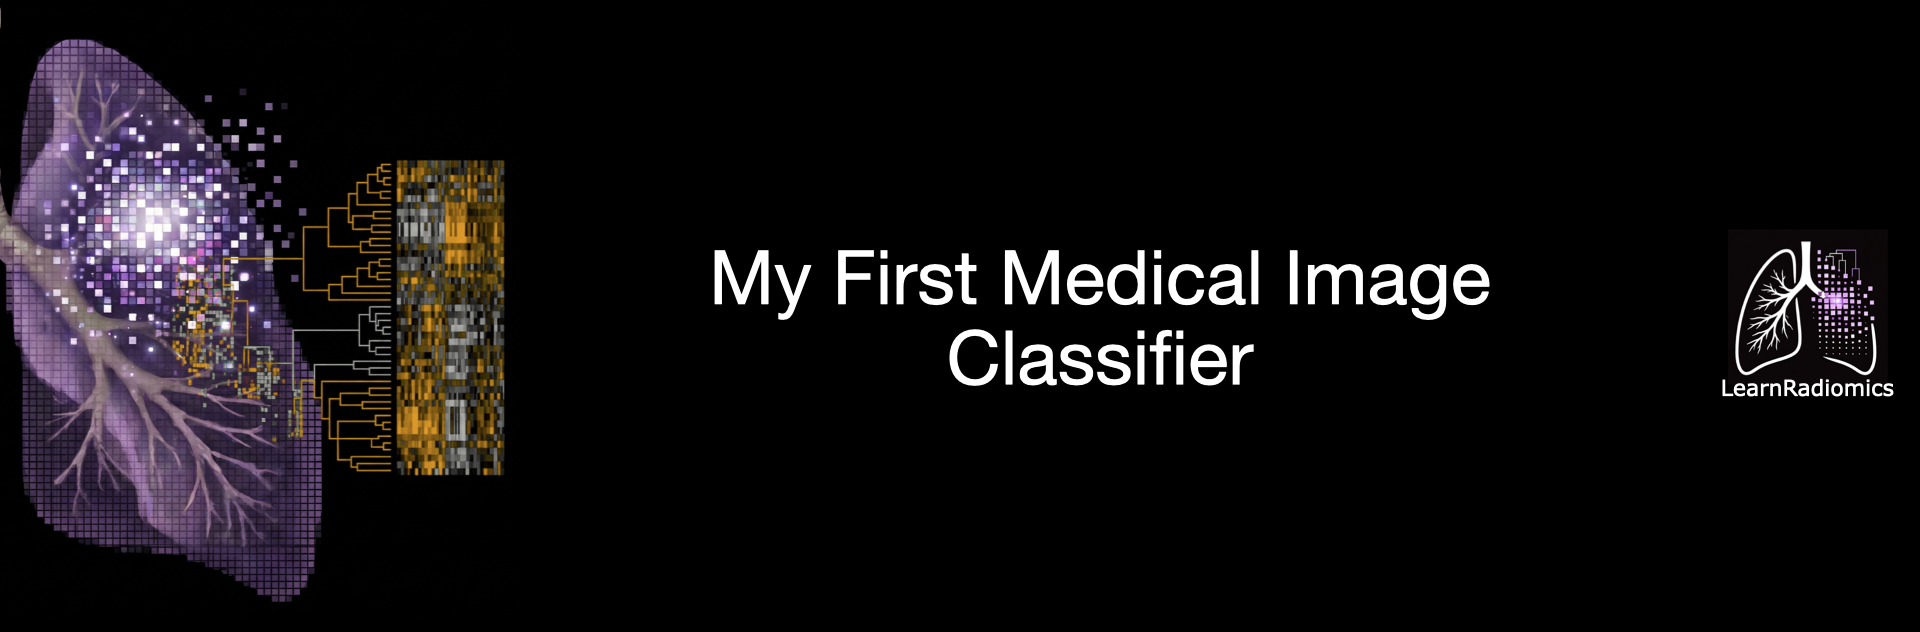

In [ ]:
!pip install medmnist

In [ ]:
## General Libraries
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import os
from medmnist import BreastMNIST
from medmnist import INFO

## Model Building
import tensorflow as tf
from keras import backend as K
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.layers import (Dense, Flatten, Dropout, Input, Conv2D,
                                     GlobalAveragePooling2D, MaxPooling2D, Flatten)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.metrics import AUC

## Warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
### Data Loading
train_dataset = BreastMNIST(split="train", size=224,  download=True)
val_dataset = BreastMNIST(split="val", size=224,  download=True) #Internal Validation
test_dataset = BreastMNIST(split="test", size=224,  download=True) #External Validation


In [ ]:
## Visualize example cases
info = INFO["breastmnist"]
labels_dict = info["label"]

img, label = train_dataset[6]
label_int = label.item()

plt.figure(figsize=(3,3))
plt.imshow(img, cmap="gray")
plt.title(f"Label: {label_int} - {labels_dict[str(label_int)]}")
plt.axis("off")
plt.show()

In [ ]:
## Random Cases
ROWS = 4
fig, axes1 = plt.subplots(ROWS,ROWS,figsize=(10,10))
for j in range(ROWS):
    for k in range(ROWS):
        i = np.random.randint(0, len(train_dataset))
        img, label = train_dataset[i]
        axes1[j][k].set_axis_off()
        axes1[j][k].imshow(img, cmap='gray')
        axes1[j][k].set_title("Label:{}".format(labels_dict[str(label.item())]), size=8)

plt.show()

In [ ]:
### Data partitioning and pre processing

X_train = train_dataset.imgs.astype("float32") / 255.0
y_train = train_dataset.labels.astype("float32")

X_val = val_dataset.imgs.astype("float32") / 255.0
y_val = val_dataset.labels.astype("float32")

X_test = test_dataset.imgs.astype("float32") / 255.0
y_test = test_dataset.labels.astype("float32")

## Reshape (imgs, width, height, channels)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

In [ ]:
## Labels examples
y_train[0:10]

### **Convolutional neural network model construction**


---



In [ ]:
## AlexNet-based model

def build_alexnet_medical(
    input_shape=(224, 224, 1),
    num_classes=1,
    final_activation="sigmoid",
    dropout_rate=0.4
):
    inputs = layers.Input(shape=input_shape)

    ## Block 1
    x = layers.Conv2D(
        32,
        kernel_size=7,
        strides=2,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name="conv1"
    )(inputs)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Activation("relu", name="relu1")(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding="same", name="pool1")(x)

    # Block 2
    x = layers.Conv2D(
        64,
        kernel_size=5,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name="conv2"
    )(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Activation("relu", name="relu2")(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding="same", name="pool2")(x)

    # Block 3
    x = layers.Conv2D(
        128,
        kernel_size=3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name="conv3"
    )(x)
    x = layers.BatchNormalization(name="bn3")(x)
    x = layers.Activation("relu", name="relu3")(x)

    # Block 4
    x = layers.Conv2D(
        128,
        kernel_size=3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name="conv4"
    )(x)
    x = layers.BatchNormalization(name="bn4")(x)
    x = layers.Activation("relu", name="relu4")(x)

    # Block 5
    x = layers.Conv2D(
        256,
        kernel_size=3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name="conv5"
    )(x)
    x = layers.BatchNormalization(name="bn5")(x)
    x = layers.Activation("relu", name="relu5")(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding="same", name="pool5")(x)

    # Head: classification
    x = layers.GlobalAveragePooling2D(name="gap")(x)

    x = layers.Dense(
        256,
        activation="relu",
        kernel_initializer="he_normal",
        name="fc1"
    )(x)
    x = layers.Dropout(dropout_rate, name="dropout1")(x)

    x = layers.Dense(
        64,
        activation="relu",
        kernel_initializer="he_normal",
        name="fc2"
    )(x)
    x = layers.Dropout(dropout_rate, name="dropout2")(x)

    outputs = layers.Dense(
        num_classes,
        activation=final_activation,
        name="prediction"
    )(x)

    model = Model(inputs, outputs, name="AlexNet_Medical_Modified")

    return model

In [ ]:
model = build_alexnet_medical(
    input_shape=(224, 224, 1),
    num_classes=1,
    final_activation="sigmoid")

model.summary()

In [ ]:

## Hyperparameters
EPOCHS = 20
BATCH_SIZE = 16
LR = 0.00001

## Callbacks:
### Scheduler: decreases the learning rate throughout training**

def scheduler(epoch, learning_rate):
  if epoch < 10:
    return learning_rate
  else:
    return learning_rate * np.exp(-0.05)

lr_scheduler = LearningRateScheduler(scheduler)

## checkpoints
checkpoint_filepath = './checkpoint.weights.h5'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True)

## Compile and fit
model.compile(optimizer=Adam(learning_rate=LR), loss = 'binary_crossentropy', metrics=['accuracy',AUC(name="roc_auc", curve="ROC") ])

history = model.fit(X_train, y_train, epochs= EPOCHS, verbose= 1, batch_size= BATCH_SIZE,
                validation_data=(X_val, y_val), shuffle= True,
                callbacks=[model_checkpoint_callback,lr_scheduler])

## The weights of the best model are loaded**
model.load_weights(checkpoint_filepath)


In [ ]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(loss))

plt.plot(epochs, accuracy, 'bo', label='Training accuracy', color='salmon')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy', color='dodgerblue')
plt.title('Training and validation accuracy')
plt.legend()
plt.show()

plt.plot(epochs, loss, 'bo', label='Training loss', color='salmon')
plt.plot(epochs, val_loss, 'b', label='Validation loss', color='dodgerblue')
plt.title('Training and validation loss')
plt.legend()
plt.show()

## Testing the model

In [ ]:
## Inference is performed on the test set
pred_scores = model.predict(X_test)

## Score binarization
y_pred = np.where(pred_scores > 0.5, 1, 0)

## metrics
print(classification_report(y_test, y_pred, target_names = ['malignant', 'normal-benign']))

In [ ]:
roc_auc_score(y_test, pred_scores)


### More Complex Model: **ResNet50**

In [ ]:
### ResNet without pretrained weights

base_model = ResNet50(
    weights=None,
    include_top=False,
    input_shape=(X_train.shape[1], X_train.shape[2], 1))

base_model.trainable = True

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

resnet_model = Model(inputs=base_model.input, outputs=output)

In [ ]:

## Hyperparameters:
EPOCHS = 50
BATCH_SIZE = 64
LR = 0.0005

def scheduler(epoch, learning_rate):
  if epoch < 10:
    return learning_rate
  else:
    return learning_rate * np.exp(-0.05)

lr_scheduler = LearningRateScheduler(scheduler)

checkpoint_filepath2 = './checkpoint_resnet.weights.h5'

model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath2,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True)

## Compile and fit
resnet_model.compile(optimizer=Adam(learning_rate=LR), loss = 'binary_crossentropy', metrics=['accuracy',AUC(name="roc_auc", curve="ROC") ])

history2 = resnet_model.fit(X_train, y_train, epochs= EPOCHS, verbose= 1, batch_size= BATCH_SIZE,
                validation_data=(X_test, y_test), shuffle= True,
                callbacks=[model_checkpoint_callback,lr_scheduler])

resnet_model.load_weights(checkpoint_filepath2)

In [ ]:
accuracy = history2.history['accuracy']
val_accuracy = history2.history['val_accuracy']
loss = history2.history['loss']
val_loss = history2.history['val_loss']

epochs = range(len(loss))

plt.plot(epochs, accuracy, 'bo', label='Training accuracy', color='salmon')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy', color='dodgerblue')
plt.title('Training and validation accuracy')
plt.legend()
plt.show()

plt.plot(epochs, loss, 'bo', label='Training loss', color='salmon')
plt.plot(epochs, val_loss, 'b', label='Validation loss', color='dodgerblue')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [ ]:
pred_scores = resnet_model.predict(X_test)
y_pred = np.where(pred_scores > 0.5, 1, 0)
print(classification_report(y_test, y_pred, target_names = ['malignant', 'normal-benign']))
print("ROC AUC:", roc_auc_score(y_test, pred_scores))